# Mini-MRV: Soil Carbon Sequestration Pipeline

End-to-end run: real SoilGrids SOC + NDVI proxy → RothC-lite model → Monte Carlo uncertainty (VMD0053) → results.

Study area: Ludhiana (Punjab) + Karnal (Haryana) — Indo-Gangetic rice-wheat belt.

In [1]:
import sys, pathlib, importlib.util
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
RAW = ROOT / 'data' / 'raw'
PROC = ROOT / 'data' / 'processed'

def load_module(name, num):
    path = ROOT / 'src' / f'{num}_{name}.py'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

print('Root:', ROOT)

Root: C:\Users\Abuza\mini-mrv-varaha


## 1. Fetch inputs (real SoilGrids SOC + NDVI proxy)

In [2]:
f1 = load_module('fetch_inputs', '01')
gdf = f1.make_districts()
soc_df = f1.fetch_soc(gdf)
soc_df = f1.calc_c_inputs(soc_df)
f1.make_climate()

Saved C:\Users\Abuza\mini-mrv-varaha\data\raw\districts.gpkg (2 districts)


SoilGrids SOC saved to C:\Users\Abuza\mini-mrv-varaha\data\raw\soc_soilgrids.csv (293 pixels). Means: {'Karnal': 32.7, 'Ludhiana': 30.9}
C inputs saved to C:\Users\Abuza\mini-mrv-varaha\data\processed\c_inputs.csv
          c_input_burn_tC_per_ha  c_input_retain_tC_per_ha  c_input_fym_tC_per_ha
district                                                                         
Karnal                      0.59                      1.20                   2.05
Ludhiana                    0.58                      1.19                   2.04
Climate modifiers saved to C:\Users\Abuza\mini-mrv-varaha\data\raw\climate_modifiers.csv


,month,f_temp,f_moist
0,Jan,0.70,0.60
1,Feb,0.75,0.55
2,Mar,0.90,0.60
3,Apr,1.10,0.50
4,May,1.40,0.45
5,Jun,1.60,0.85
6,Jul,1.55,1.30
7,Aug,1.45,1.25
8,Sep,1.20,0.90
9,Oct,0.95,0.60


In [3]:
soc_df.head(10)

,district,lon,lat,soc_0_30_tC_per_ha,ndvi,c_input_retain_tC_per_ha,c_input_burn_tC_per_ha,c_input_fym_tC_per_ha
0,Ludhiana,75.400775,30.998877,29.0,0.655242,1.953831,0.937839,2.803831
1,Ludhiana,75.458415,30.998877,30.0,0.482725,1.004988,0.482394,1.854988
2,Ludhiana,75.516055,30.998877,32.0,0.522626,1.224441,0.587732,2.074441
3,Ludhiana,75.573694,30.998877,28.0,0.552601,1.389307,0.666867,2.239307
4,Ludhiana,75.631334,30.998877,32.0,0.456886,0.862874,0.414179,1.712874
5,Ludhiana,75.688973,30.998877,30.0,0.520165,1.210909,0.581236,2.060909
6,Ludhiana,75.804252,30.998877,31.0,0.519929,1.209608,0.580612,2.059608
7,Ludhiana,75.919532,30.998877,32.0,0.379622,0.437921,0.300000,1.287921
8,Ludhiana,75.977171,30.998877,37.0,0.601413,1.657770,0.795729,2.507770
9,Ludhiana,76.092450,30.998877,33.0,0.568040,1.474219,0.707625,2.324219


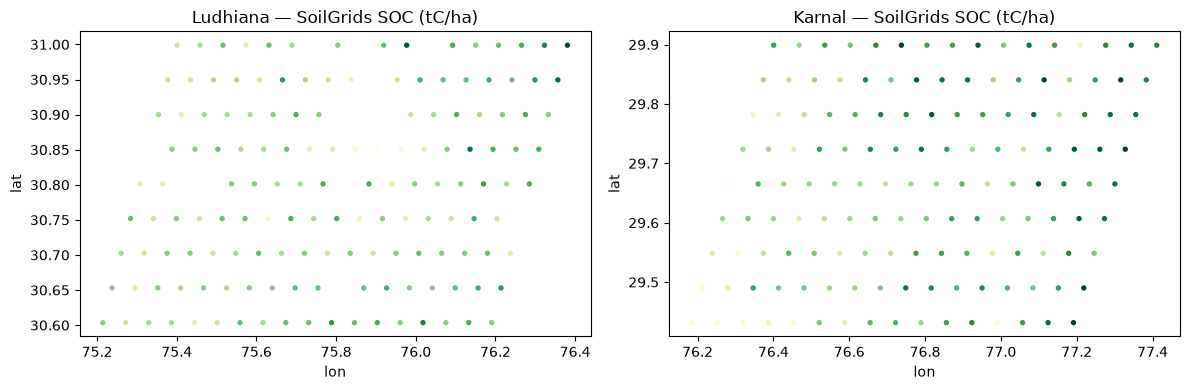

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, d in enumerate(['Ludhiana', 'Karnal']):
    sub = soc_df[soc_df['district'] == d]
    ax[i].scatter(sub['lon'], sub['lat'], c=sub['soc_0_30_tC_per_ha'], s=8, cmap='YlGn')
    ax[i].set_title(f'{d} — SoilGrids SOC (tC/ha)')
    ax[i].set_xlabel('lon'); ax[i].set_ylabel('lat')
plt.tight_layout(); plt.show()

## 2. Run RothC-lite model (20-year SOC trajectory)

In [5]:
m2 = load_module('rothc_lite_model', '02')
m2.main()

=== 02_rothc_lite_model: running scenarios ===


Saved 879 rows to C:\Users\Abuza\mini-mrv-varaha\data\processed\results.csv
                    tco2e_per_ha_per_year  incremental_tco2e_vs_baseline
district scenario                                                       
Karnal   CT_burn                   -2.671                          0.000
         ZT_FYM                    -0.201                          2.470
         ZT_retain                 -1.430                          1.241
Ludhiana CT_burn                   -2.786                          0.000
         ZT_FYM                    -0.372                          2.414
         ZT_retain                 -1.561                          1.225

Incremental = project - baseline (CT_burn). Positive = carbon credit.
Next: python src/03_uncertainty.py


In [6]:
results = pd.read_csv(PROC / 'results.csv')
results.head(10)

,pixel_id,district,soc0,scenario,c_input,soc_final_20y,delta_soc_20y,delta_soc_per_year,tco2e_per_ha_per_year,incremental_tco2e_vs_baseline
0,0,Ludhiana,29.0,CT_burn,0.937839,15.406357,-13.593643,-0.679682,-2.494433,0.000000
1,0,Ludhiana,29.0,ZT_retain,1.953831,23.617294,-5.382706,-0.269135,-0.987727,1.506707
2,0,Ludhiana,29.0,ZT_FYM,2.803831,31.527018,2.527018,0.126351,0.463708,2.958141
3,1,Ludhiana,30.0,CT_burn,0.482394,15.117567,-14.882433,-0.744122,-2.730927,0.000000
4,1,Ludhiana,30.0,ZT_retain,1.004988,21.257492,-8.742508,-0.437125,-1.604250,1.126676
5,1,Ludhiana,30.0,ZT_FYM,1.854988,27.388969,-2.611031,-0.130552,-0.479124,2.251802
6,2,Ludhiana,32.0,CT_burn,0.587732,16.248429,-15.751571,-0.787579,-2.890413,0.000000
7,2,Ludhiana,32.0,ZT_retain,1.224441,23.150854,-8.849146,-0.442457,-1.623818,1.266595
8,2,Ludhiana,32.0,ZT_FYM,2.074441,29.693613,-2.306387,-0.115319,-0.423222,2.467191
9,3,Ludhiana,28.0,CT_burn,0.666867,14.473924,-13.526076,-0.676304,-2.482035,0.000000


In [7]:
summary = results.groupby(['district', 'scenario'])[['tco2e_per_ha_per_year', 'incremental_tco2e_vs_baseline']].mean().round(3)
summary

tco2e_per_ha_per_year  incremental_tco2e_vs_baseline
district scenario                                                       
Karnal   CT_burn                   -2.671                          0.000
         ZT_FYM                    -0.201                          2.470
         ZT_retain                 -1.430                          1.241
Ludhiana CT_burn                   -2.786                          0.000
         ZT_FYM                    -0.372                          2.414
         ZT_retain                 -1.561                          1.225

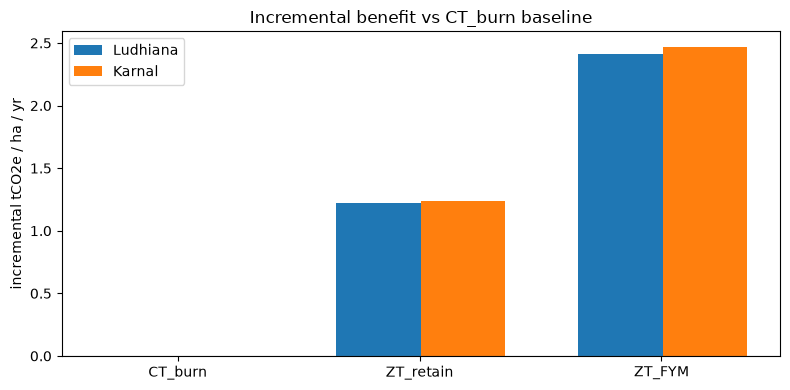

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
scenarios = ['CT_burn', 'ZT_retain', 'ZT_FYM']
x = np.arange(len(scenarios))
for i, d in enumerate(['Ludhiana', 'Karnal']):
    vals = [results[(results['district']==d) & (results['scenario']==s)]['incremental_tco2e_vs_baseline'].mean() for s in scenarios]
    ax.bar(x + i*0.35 - 0.17, vals, 0.35, label=d)
ax.set_xticks(x); ax.set_xticklabels(scenarios)
ax.set_ylabel('incremental tCO2e / ha / yr'); ax.set_title('Incremental benefit vs CT_burn baseline')
ax.axhline(0, color='gray', lw=0.8); ax.legend()
plt.tight_layout(); plt.show()

## 3. Monte Carlo uncertainty (VMD0053)

In [9]:
m3 = load_module('uncertainty', '03')
m3.main(n_runs=1000)

=== 03_uncertainty: Monte Carlo n=1000 ===


Karnal ZT_FYM width 1.87 > 0.5*|mean| so conservative = p5 (-1.098)


district  scenario  mean_tco2e    sd     p5    p25    p75    p95  width_p90  deduction_triggered  conservative_tco2e
  Karnal   CT_burn      -2.641 0.447 -3.348 -2.949 -2.339 -1.874      1.474                 True              -3.348
  Karnal    ZT_FYM      -0.194 0.577 -1.098 -0.605  0.221  0.774      1.871                 True              -1.098
  Karnal ZT_retain      -1.399 0.427 -2.109 -1.702 -1.107 -0.697      1.411                 True              -2.109
Ludhiana   CT_burn      -2.771 0.419 -3.436 -3.061 -2.489 -2.043      1.393                 True              -3.436
Ludhiana    ZT_FYM      -0.377 0.540 -1.210 -0.745 -0.048  0.537      1.747                 True              -1.210
Ludhiana ZT_retain      -1.521 0.382 -2.152 -1.768 -1.266 -0.859      1.293                 True              -2.152

Saved uncertainty_summary.csv and uncertainty_draws.csv to C:\Users\Abuza\mini-mrv-varaha\data\processed
Next: streamlit run src/04_streamlit_app.py


In [10]:
unc = pd.read_csv(PROC / 'uncertainty_summary.csv')
unc

,district,scenario,mean_tco2e,sd,p5,p25,p75,p95,width_p90,deduction_triggered,conservative_tco2e
0,Karnal,CT_burn,-2.641,0.447,-3.348,-2.949,-2.339,-1.874,1.474,True,-3.348
1,Karnal,ZT_FYM,-0.194,0.577,-1.098,-0.605,0.221,0.774,1.871,True,-1.098
2,Karnal,ZT_retain,-1.399,0.427,-2.109,-1.702,-1.107,-0.697,1.411,True,-2.109
3,Ludhiana,CT_burn,-2.771,0.419,-3.436,-3.061,-2.489,-2.043,1.393,True,-3.436
4,Ludhiana,ZT_FYM,-0.377,0.540,-1.210,-0.745,-0.048,0.537,1.747,True,-1.210
5,Ludhiana,ZT_retain,-1.521,0.382,-2.152,-1.768,-1.266,-0.859,1.293,True,-2.152


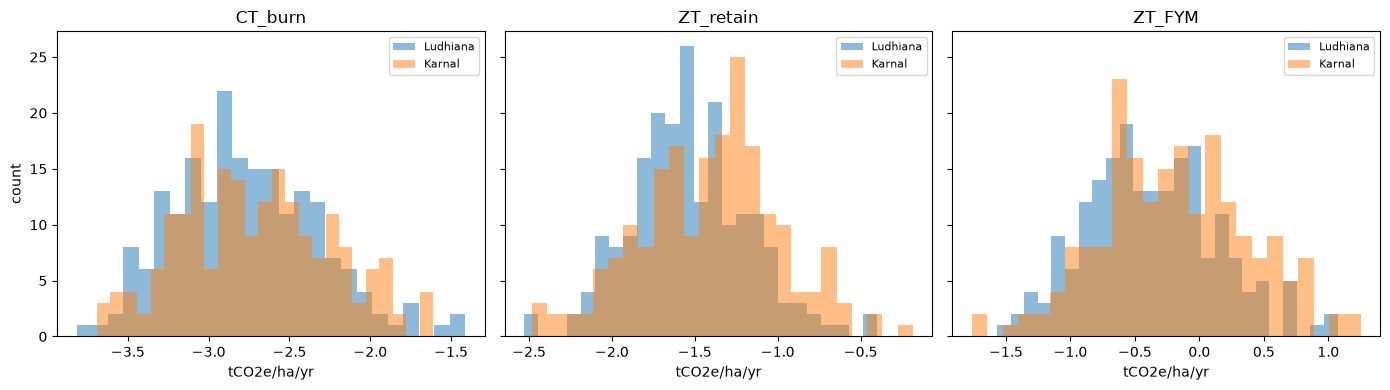

In [11]:
draws = pd.read_csv(PROC / 'uncertainty_draws.csv')
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, s in enumerate(['CT_burn', 'ZT_retain', 'ZT_FYM']):
    sub = draws[draws['scenario'] == s]
    for d in ['Ludhiana', 'Karnal']:
        axes[i].hist(sub[sub['district']==d]['tco2e_draw'], bins=25, alpha=0.5, label=d)
    axes[i].set_title(s); axes[i].set_xlabel('tCO2e/ha/yr'); axes[i].legend(fontsize=8)
axes[0].set_ylabel('count')
plt.tight_layout(); plt.show()

## 4. Generate PDF report

In [12]:
m5 = load_module('report', '05')
m5.build_pdf()
print('PDF saved to reports/Mini_MRV_Report_VM0042.pdf')

Saved report to C:\Users\Abuza\mini-mrv-varaha\reports\Mini_MRV_Report_VM0042.pdf
PDF saved to reports/Mini_MRV_Report_VM0042.pdf


## Summary

- **SoilGrids SOC** fetched via ISRIC WebDAV (real, 250m OCS 0-30cm)
- **NDVI** is a mock proxy (real would be Planetary Computer STAC)
- **RothC-lite** (not DayCent) ran 20-year SOC trajectories for 3 scenarios x 2 districts
- **incremental_tco2e_vs_baseline** = project minus CT_burn — this is the credit
- **Monte Carlo** (1000 runs) with VMD0053 conservative deduction
- **PDF report** generated

ZT_FYM shows the highest incremental benefit vs CT_burn — the credit-relevant signal.